<a href="https://colab.research.google.com/github/EngZiadSoliman/cifar10-cnn-classifier/blob/main/CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

In [ ]:
model = models.Sequential([
    # improved architecture (Conv2D + BatchNorm + Dropout)
])

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10)  # CIFAR-10 classes
])

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=15,
    validation_data=(x_test, y_test)
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 54ms/step - accuracy: 0.3670 - loss: 1.7292 - val_accuracy: 0.3934 - val_loss: 1.7094
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5155 - loss: 1.3512 - val_accuracy: 0.6021 - val_loss: 1.1278
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6036 - loss: 1.1387 - val_accuracy: 0.6354 - val_loss: 1.0821
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.6523 - loss: 1.0147 - val_accuracy: 0.6265 - val_loss: 1.2586
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.6890 - loss: 0.9220 - val_accuracy: 0.7078 - val_loss: 0.8536
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7191 - loss: 0.8422 - val_accuracy: 0.7600 - val_loss: 0.7103
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7386 - loss: 0.7886 - val_accuracy: 0.7603 - val_loss: 0.7338
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7552 - loss: 0.7308 - 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7801 - loss: 0.7119
Test accuracy: 0.7800999879837036


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


/tmp/ipykernel_26060/3262083807.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = class_names[int(y_test[i])]


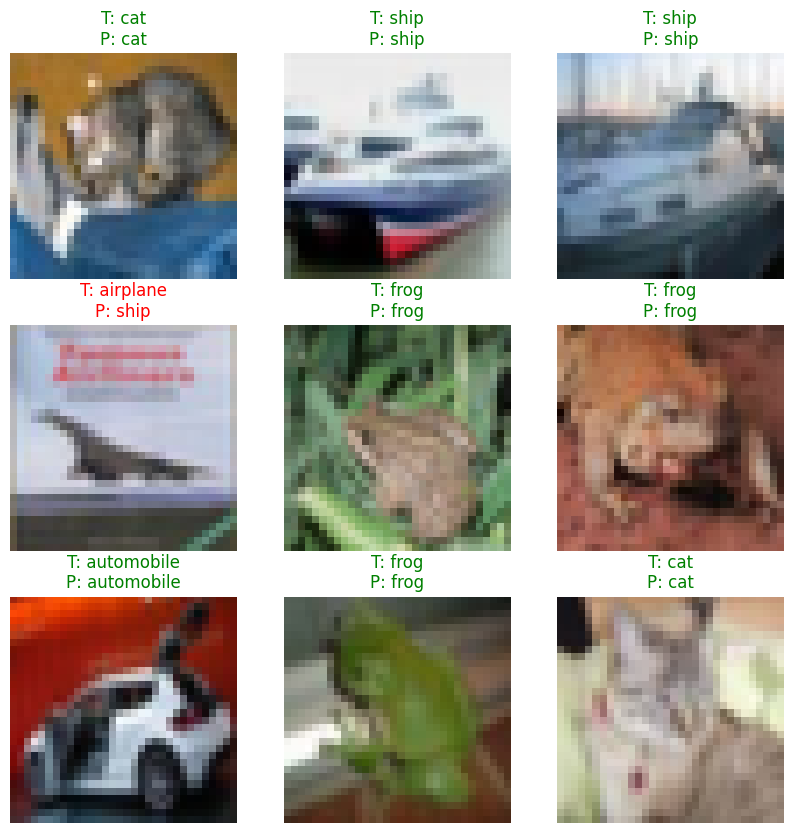

In [ ]:
# Map numeric labels to class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Get predictions
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

# Show some test images with predicted labels
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i])
    true_label = class_names[int(y_test[i])]
    pred_label = class_names[predicted_labels[i]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
    plt.axis('off')
plt.show()

In [ ]:
model.save('saved_model/cifar10_cnn_model.h5')